# Approximate Bayesian Computation

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/gem-epidemics/colab/blob/master/iddinf/approximate_bayesian_computation.ipynb)

## LEARNING OUTCOMES

- explain why simulation-based (likelihood-free) inference is useful for
  epidemic models specifically
- implement an ABC rejection sampler given a simulator, a summary
  statistic, and a tolerance
- reason about the tolerance / acceptance-rate / bias tradeoff
- compare an ABC posterior against an MCMC posterior and understand when it's best to use an ABC

## Introduction

Unlike the MCMC methods you've just used, which need the model's exact
likelihood to evaluate at every parameter value, ABC
doesn't require a likelihood at all.

Stochastic epidemic models often
have likelihoods that are either intractable or difficult to compute. For example, the exact transition times between states (e.g. the time someone was infected) are usually unobserved, and only aggregated counts are available.

Rather than deriving or approximating that likelihood directly,
**Approximate Bayesian Computation (ABC)** sidesteps it entirely: if you
can *simulate* from the model, you can compare simulated outbreaks to
the observed one, and keep only the parameter values that produced
something similar.

All ABC needs is a data generating model.

### ABC rejection sampler

There are many variations of ABC that build on this idea, but today we will cover the simplest  - the rejection sampler.

ABC rejection sampling works as follows:

1. Sample θ* from the prior distribution p(θ).
2. Simulate a data D* from the model, using parameters θ*.
3. If d(D, D*) < ε, accept θ*; otherwise, reject.
4. Repeat for N candidate values θ*₁, …, θ*ₙ. The accepted values form an approximate sample from the posterior p(θ | D).

The quality of the approximation is controlled by two choices:

*   The summary statistic you choose to compare on.
*   The tolerance ϵ that you accept within.


## ABC in practice

In this section we will use the `gemlib` ABC rejection
sampler to recover the transmission rate `beta` from a simple homogeneous SIR model.

**Building an example model**

Let's develop an example model as we have done before.

Firstly, install the gemlib library.


In [38]:
from warnings import warn

try:
    import google.colab

    !pip install -Uq gemlib
except:
    warn("Not running in Colab, make sure `gemlib` is installed locally")

/var/folders/36/s7ymq7cn18bf5x8xvy9dz0700000gn/T/ipykernel_95740/1081509697.py:8: UserWarning: Not running in Colab, make sure `gemlib` is installed locally
  warn("Not running in Colab, make sure `gemlib` is installed locally")


We can now import the modules needed for this notebook.

In [39]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import tensorflow_probability.substrates.jax as tfp
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from collections import namedtuple

import gemlib
from gemlib.abc.abc_rejection_sampler import abc_rejection_sampler
from gemlib.distributions import DiscreteTimeStateTransitionModel
from gemlib.mcmc.mcmc_sampler import mcmc
from gemlib.mcmc.adaptive_random_walk_metropolis import adaptive_rwmh

tfd = tfp.distributions
DTYPE = np.float32

### The epidemic model
We're going to model our epidemic with a simple homogeneous SIR model.

We have 3 _states_: $S$, $I$, and $R$ representing susceptible, infected, and recovered individuals respectively.

We then have two transitions, $S \rightarrow I$ and $I \rightarrow R$, for which we assume transition rates:

\begin{align*}
\lambda^{SI} &= \beta I/N \\  
\lambda^{IR} &= \gamma
\end{align*}

### Incidence matrix

In [40]:
incidence_matrix = np.array(
    [  #  SI  IR
        [-1, 0],  # S
        [1, -1],  # I
        [0, 1],  # R
    ],
    dtype=DTYPE,
)

### Initial state

In [41]:
initial_state = np.array(
    [
        [99, 1, 0],
    ]
).astype(DTYPE)

### The discrete-time model

W can now instantiate the `DiscreteTimeStateTransitionModel`.

In [42]:
def sir_model(beta, gamma):

    def si_rate(t, state):
        return beta * state[:, 1] / state.sum(axis=-1)

    def ir_rate(t, state):
        return gamma

    return DiscreteTimeStateTransitionModel(
        transition_rate_fn=[si_rate, ir_rate],
        incidence_matrix=incidence_matrix,
        initial_state=initial_state,
        initial_step=0,
        time_delta=1.0,
        num_steps=200,
        name="events",
    )

### Generate the 'observed data'

We want to see if we can recover the transmission rate `beta` with the ABC rejection sampler.

We set our parameter of interest as `true_beta` = 0.5 and sample from the `sir_model` defined above.

In [43]:
true_beta = 0.5
gamma = 0.2

obs_key = jax.random.key(1)

```{exercise}
:label: ex13.1

1. Sample from the `sir_model` using the parameters and seed defined above.

2. Compute `obs_total` from your sample, this should be the number of total new infections (S->I transitions).
```

````{solution-start} ex13.1
:class: dropdown
````

In [44]:
# define a function to calculate the number of new infections


def total_new_infections(events):
    """Total number of S->I transitions."""
    return jnp.sum(events[..., 0], axis=(-2, -1))

In [45]:
obs_events = sir_model(beta=true_beta, gamma=gamma).sample(seed=obs_key)

obs_total = float(total_new_infections(obs_events))
print(f"obs_total = {obs_total}")


obs_total = 93.0


````{solution-end}
````

### Checking the observed total number of infections

A single-seed outbreak has a chance of never taking off. Check you have a decent size outbreak using an assert.

In [46]:
# A single-seed outbreak has a chance of early extinction
assert obs_total > 10
print(f"obs_total = {obs_total}")

obs_total = 93.0


### Bayesian model

We can now define a prior for the `beta` parameter that we are trying to estimate.

In [47]:
beta_prior = tfd.LogNormal(loc=jnp.log(0.4), scale=0.4, name="beta")

Let's plot the prior distribution too.

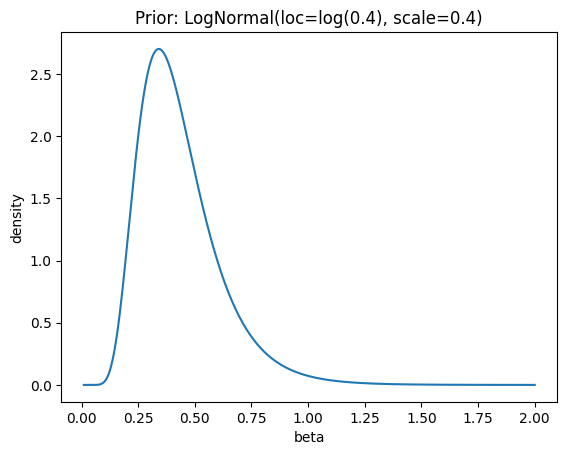

In [48]:
beta_grid = jnp.linspace(0.01, 2.0, 500)
density = beta_prior.prob(beta_grid)

plt.plot(beta_grid, density)
plt.xlabel("beta")
plt.ylabel("density")
plt.title("Prior: LogNormal(loc=log(0.4), scale=0.4)")
plt.show()

Now as before we decorate our Bayesian mdoel function with `@tfd.JointDistributionCoroutineAutoBatched`.

In [49]:
@tfd.JointDistributionCoroutineAutoBatched
def model():
    # draw beta from its prior
    beta = yield beta_prior

    # yield the SIR event-data distribution given beta value
    events = yield sir_model(beta=beta, gamma=gamma)

```{exercise}
:label: ex13.2 
`abc_rejection_sampler` takes an `accept_fn` --# a function that decides,
for a whole batch of simulated samples at once, which ones to *keep*.
It should return a boolean array: `True` where the simulated outbreak
is close enough to the observed one, `False` otherwise.

1. Fill in `accept_fn` below: compare `total_new_infections(samples.events)`
against `obs_total`, accepting a sample if the absolute difference is
less than your tolerance `epsilon`.

```

````{solution-start} ex13.2
:class: dropdown
````

In [50]:
epsilon = 12.0

num_samples = 1000


def accept_fn(samples):
    return jnp.abs(total_new_infections(samples.events) - obs_total) < epsilon

````{solution-end}
````

### Running the ABC sampler

Now we've written the acceptance function we can run the abc_rejection_sampler.

In [51]:
seed = jax.random.key(11)
posterior, rate = abc_rejection_sampler(
    accept_fn=accept_fn,
    num_samples=num_samples,
    model=model,
    key=seed,
)

Let's plot the posterior samples for beta and check the acceptance rate.

acceptance rate: 0.391
number of accepted samples: 391
posterior mean beta: 0.571 (true beta = 0.5)


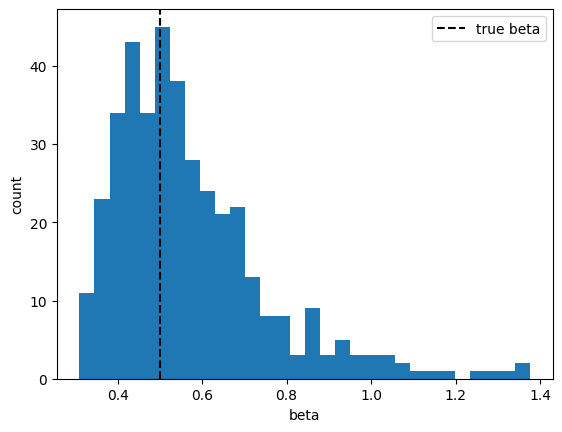

In [52]:
print(f"acceptance rate: {rate:.3f}")
print(f"number of accepted samples: {posterior.beta.shape[0]}")
print(
    f"posterior mean beta: {float(jnp.mean(posterior.beta)):.3f} (true beta = {true_beta})"
)

plt.hist(np.asarray(posterior.beta), bins=30)
plt.axvline(true_beta, color="k", linestyle="--", label="true beta")
plt.xlabel("beta")
plt.ylabel("count")
plt.legend()
plt.show()

```{exercise}
:label: ex13.3
Discuss in pairs: 
1. What acceptance rate did you get? What happens to it if you halve
  `epsilon`?
2. What would have happened if `obs_total` had come from a simulated outbreak that went extinct almost immediately (a total of < **5** infections)? Would tightening or loosening `epsilon` fix it?

```

## The tolerance / acceptance-rate tradeoff

This is the conceptual heart of ABC. Sweep `epsilon` across a range of
values, and for each one, record the acceptance rate and the posterior
mean and standard deviation of `beta`.

In [53]:
# iterate over each value in `epsilons`
epsilons = jnp.array([2.0, 5.0, 10.0, 20.0, 40.0, 80.0, 100, 120.0])

# create three empty arrays to append to
rates, means, stds = [], [], []

for i, eps in enumerate(epsilons):

    def accept_fn(samples):
        return jnp.abs(total_new_infections(samples.events) - obs_total) < eps

    posterior_i, rate_i = abc_rejection_sampler(
        accept_fn=accept_fn,
        num_samples=num_samples,
        model=model,
        key=jax.random.fold_in(seed, i),
    )
    n_accepted = posterior_i.beta.shape[0]
    rates.append(float(rate_i))
    means.append(float(jnp.mean(posterior_i.beta)) if n_accepted else np.nan)
    stds.append(float(jnp.std(posterior_i.beta)) if n_accepted else np.nan)

```{exercise}
:label: ex13.4
1. Using the `rates`, `means` and `stds` you just computed, create two plots:
*   Acceptance rate vs `epsilon`.
*   Posterior mean and standard deviation of beta vs `epsilon`.

2. Discuss in pairs - what's the tradeoff you see in these two plots? What would you have to do to use a much smaller `epsilon` in practice?
```

````{solution-start} ex13.4
:class: dropdown
````

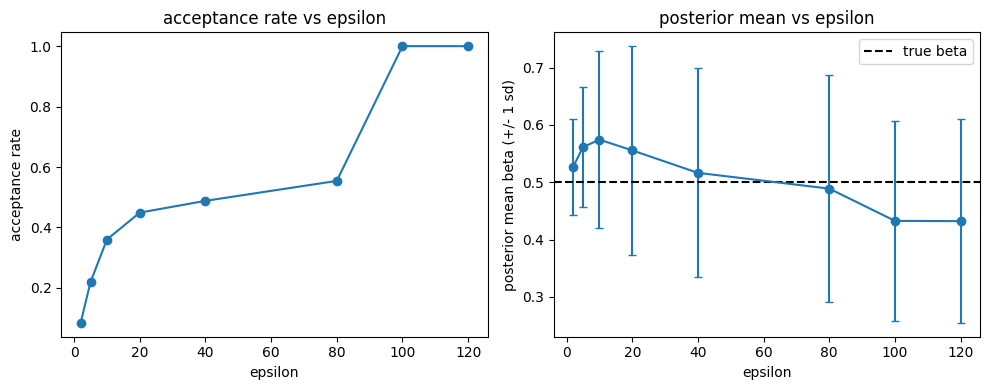

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(epsilons, rates, marker="o")
axes[0].set(
    xlabel="epsilon", ylabel="acceptance rate", title="acceptance rate vs epsilon"
)

axes[1].errorbar(epsilons, means, yerr=stds, marker="o", capsize=3)
axes[1].axhline(true_beta, color="k", linestyle="--", label="true beta")
axes[1].set(
    xlabel="epsilon",
    ylabel="posterior mean beta (+/- 1 sd)",
    title="posterior mean vs epsilon",
)
axes[1].legend()

plt.tight_layout()
plt.show()

````{solution-end}
````

## Comparing ABC with MCMC on a discrete-time metapopulation model.

### The model
We define our population as a composition of 4 distinct units (sub-populations) in which individuals are classified into susceptible, infected, and removed compartments -- S, I, and R respectively.


We define a fixed **contact matrix** $C$ that
describes how much of population $j$'s infectious pressure "leaks" into
population $i$. Population 0 acts as a hub (e.g. a city); populations 1-3 are towns that commute to the hub far more than to each other.

For metapopulation $i$ at time $t$, the infection rate is:

$$
\lambda^{\mathrm{SI}}_i(\mathbf{x}_t) = \beta_1 \frac{x_{it}^{\mathrm I}}{n_i} + \beta_2 \sum_j C_{ij} \frac{x_{jt}^{\mathrm I}}{n_j}
$$

$$
\lambda^{\mathrm{IR}}_i(\mathbf{x}_t) = \gamma
$$

where $\beta_1$ is the **within-population** transmission rate and
$\beta_2$ is the **between-population** transmission rate -- i.e. how
strongly infection pressure from a metapopulation's neighbours (weighted
by $C$) feeds into its own force of infection.

In [55]:
incidence_matrix = np.array(
    [  #  SI  IR
        [-1, 0],  # S
        [1, -1],  # I
        [0, 1],  # R
    ],
    dtype=DTYPE,
)

In [56]:
initial_state = np.array(
    [[5000, 0, 0], [999, 1, 0], [1000, 0, 0], [1000, 0, 0]]
).astype(DTYPE)

In [57]:
contact_mat = np.array(
    [
        [0.00, 0.6, 0.50, 0.70],
        [0.50, 0.00, 0.05, 0.25],
        [0.40, 0.05, 0.00, 0.25],
        [0.55, 0.08, 0.25, 0.00],
    ],
    dtype=DTYPE,
)

gamma = 0.2

In [58]:
def metapop_sir_model(beta1, beta2):
    def si_rate(t, state):
        popsize = jnp.sum(state, axis=-1)
        within = state[:, 1] / popsize
        between = jnp.matvec(contact_mat, state[:, 1] / popsize)
        return beta1 * within + beta2 * between

    def ir_rate(t, state):
        return gamma

    return DiscreteTimeStateTransitionModel(
        transition_rate_fn=[si_rate, ir_rate],
        incidence_matrix=incidence_matrix,
        initial_state=initial_state,
        num_steps=100,
        name="events",
    )

Now we've instantiated the model let's compute the observed number of new infections per metapopulation and in total.

In [59]:
def per_metapop_total(events):
    return jnp.sum(events[..., 0], axis=-2)


def per_metapop_frac(events):
    # fractions as populations are unequal sizes
    return per_metapop_total(events) / jnp.sum(initial_state, axis=-1)


true_beta1 = DTYPE(0.25)  # within-population transmission
true_beta2 = DTYPE(0.075)  # between-population transmission

obs_events = metapop_sir_model(true_beta1, true_beta2).sample(seed=jax.random.key(1))
obs_states = metapop_sir_model(true_beta1, true_beta2).compute_state(obs_events)

obs_events = metapop_sir_model(true_beta1, true_beta2).sample(seed=jax.random.key(1))
obs_frac = np.array(per_metapop_frac(obs_events))
print(f"obs fractions = {np.round(obs_frac, 3)}")
print(f"per-metapopulation new infections = {per_metapop_total(obs_events)}")

obs fractions = [0.81  0.758 0.686 0.678]
per-metapopulation new infections = [4050.  758.  686.  678.]


In [60]:
def plot_timeseries(times, states, plot_height=4, labels=["S", "I", "R"], alpha=1.0):
    num_plots = states.shape[-2]
    fig, ax = plt.subplots(
        1, num_plots, figsize=(num_plots * plot_height * 1.5, plot_height)
    )
    if num_plots == 1:
        ax = [ax]
    for i in range(num_plots):
        for s, label in enumerate(labels):
            state = np.transpose(states[..., i, s])
            ax[i].plot(
                np.transpose(times), state, label=label, color=f"C{s}", alpha=alpha
            )
        ax[i].set_xlabel("Time")
        ax[i].set_ylabel("Individuals")
        leg_lines = [Line2D([0], [0], color=f"C{s}") for s in range(len(labels))]
        ax[i].legend(leg_lines, labels)
    return fig, ax

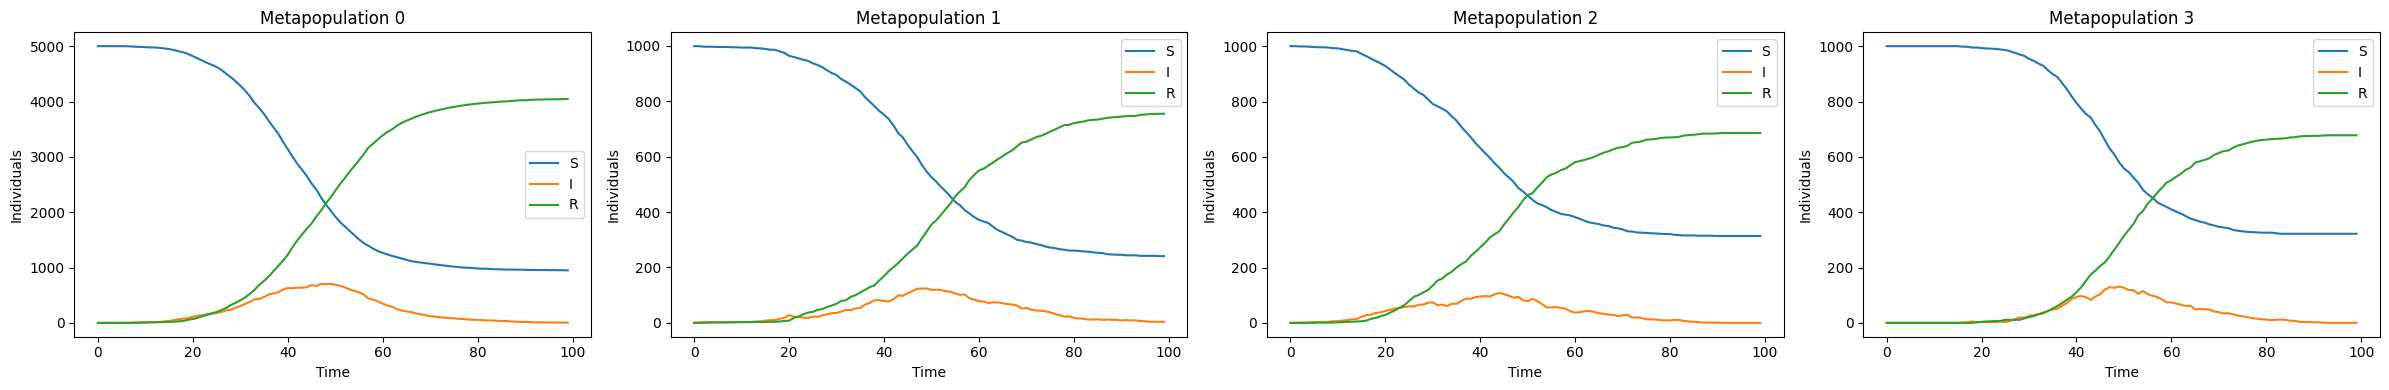

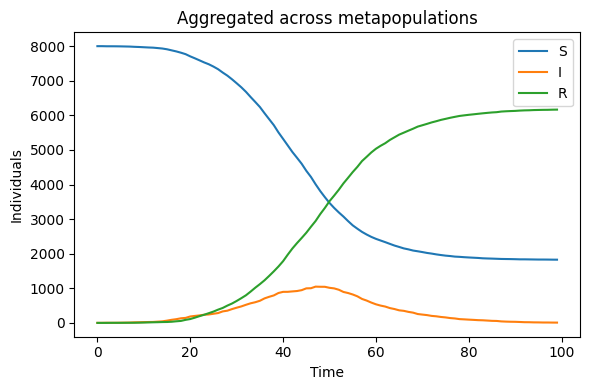

In [61]:
# epidemic trajectory in each metapopulation
fig1, ax1 = plot_timeseries(np.arange(obs_states.shape[0]), obs_states)
for i, a in enumerate(ax1):
    a.set_title(f"Metapopulation {i}")
fig1.tight_layout()

# aggregate case counts
agg_states = obs_states.sum(axis=-2, keepdims=True)  # (num_steps, 1, num_states)
fig2, ax2 = plot_timeseries(np.arange(agg_states.shape[0]), agg_states)
ax2[0].set_title("Aggregated across metapopulations")
fig2.tight_layout()

plt.show()

We can now define the Bayesian model, used by both the ABC and MCMC. We define the prior distribution for `beta_1` and `beta_2` and yield the event distribution, calling `metapop_sir_model` (wording here might need to be improved).

In [62]:
@tfd.JointDistributionCoroutineAutoBatched
def model():
    beta1 = yield tfd.LogNormal(
        loc=jnp.log(DTYPE(0.25)), scale=DTYPE(0.4), name="beta1"
    )
    beta2 = yield tfd.LogNormal(
        loc=jnp.log(DTYPE(0.08)), scale=DTYPE(0.8), name="beta2"
    )

    events = yield metapop_sir_model(beta1=beta1, beta2=beta2)

```{exercise}
:label: ex13.5
Fill in the gaps of the (i) abc code and the (ii) MCMC code
```

ABC code:

In [63]:
# un-comment the code below and fill in the missing parts

# tolerance - within a fraction of the meatpopulation total (improve wording)
# epsilon = 0.2

# def accept_fn(samples):
#     #sim_frac = # calculate the per_metapopulation_frac from the samples
#     #dist =     # calculate the euclidean distance between sim_frac and obs_frac
#     #return    # return the accepted samples
#     raise NotImplementedError


# abc_posterior, acc_rate = abc_rejection_sampler(
#     accept_fn=accept_fn,
#     num_samples=10000,
#     model=model,
#     key=jax.random.key(12),
# )

# print(f"acceptance rate = {acc_rate:.3f}")
# print(f"n accepted      = {abc_posterior.beta1.shape[0]}")
# print(f"beta1: mean={abc_posterior.beta1.mean():.3f}  std={abc_posterior.beta1.std():.3f}")
# print(f"beta2: mean={abc_posterior.beta2.mean():.3f}  std={abc_posterior.beta2.std():.3f}")
# print(f"corr(beta1, beta2) = {np.corrcoef(abc_posterior.beta1, abc_posterior.beta2)[0, 1]:.3f}")

MCMC code:

In [64]:
# un-comment the code below and fill in the missing parts

# Position = namedtuple("Position", ["beta1", "beta2"])

# def target_log_density_fn(beta1, beta2):
#     return # To do

# initial_position = # To do

# trace_position, trace_info = mcmc(
#     num_samples=5000,
#     sampling_algorithm=adaptive_rwmh(),
#     target_log_density_fn=target_log_density_fn,
#     initial_position=initial_position,
#     seed=jax.random.key(5),
# )

````{solution-start} ex13.5
:class: dropdown
````

In [65]:
# ABC code

epsilon = 0.2


def accept_fn(samples):
    sim_frac = per_metapop_frac(samples.events)
    dist = jnp.sqrt(jnp.sum((sim_frac - obs_frac) ** 2, axis=-1))
    return dist < eps


abc_posterior, acc_rate = abc_rejection_sampler(
    accept_fn=accept_fn,
    num_samples=10000,
    model=model,
    key=jax.random.key(12),
)

print(f"acceptance rate = {acc_rate:.3f}")
print(f"n accepted      = {abc_posterior.beta1.shape[0]}")
print(
    f"beta1: mean={abc_posterior.beta1.mean():.3f}  std={abc_posterior.beta1.std():.3f}"
)
print(
    f"beta2: mean={abc_posterior.beta2.mean():.3f}  std={abc_posterior.beta2.std():.3f}"
)
print(
    f"corr(beta1, beta2) = {np.corrcoef(abc_posterior.beta1, abc_posterior.beta2)[0, 1]:.3f}"
)

acceptance rate = 1.000
n accepted      = 10000
beta1: mean=0.272  std=0.115
beta2: mean=0.110  std=0.101
corr(beta1, beta2) = 0.020


In [66]:
# MCMC code

Position = namedtuple("Position", ["beta1", "beta2"])


def target_log_density_fn(beta1, beta2):
    return model.log_prob(beta1=beta1, beta2=beta2, events=obs_events)


initial_position = Position(beta1=jnp.array(0.01, DTYPE), beta2=jnp.array(0.2, DTYPE))

trace_position, trace_info = mcmc(
    num_samples=5000,
    sampling_algorithm=adaptive_rwmh(),
    target_log_density_fn=target_log_density_fn,
    initial_position=initial_position,
    seed=jax.random.key(5),
)

````{solution-end}
````

Now let's plot the traceplots for the MCMC and check we've run the chain for
long enough and selected an appropriate burn-in.

In [67]:
burnin = 100
mcmc_beta1 = np.array(trace_position.beta1[burnin:])
mcmc_beta2 = np.array(trace_position.beta2[burnin:])

print(f"beta1: mean={mcmc_beta1.mean():.3f}  std={mcmc_beta1.std():.3f}")
print(f"beta2: mean={mcmc_beta2.mean():.3f}  std={mcmc_beta2.std():.3f}")
print(f"corr(beta1, beta2) = {np.corrcoef(mcmc_beta1, mcmc_beta2)[0, 1]:.3f}")

beta1: mean=0.263  std=0.011
beta2: mean=0.066  std=0.008
corr(beta1, beta2) = -0.917


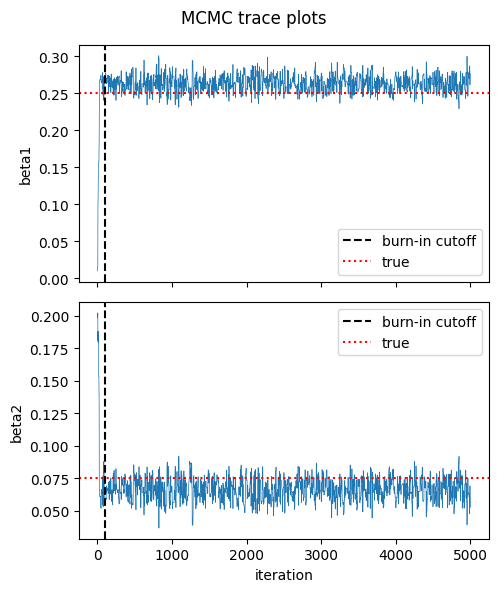

In [68]:
fig, axes = plt.subplots(2, 1, figsize=(5, 6), sharex=True)

axes[0].plot(trace_position.beta1, lw=0.5)
axes[0].axvline(burnin, color="k", linestyle="--", label="burn-in cutoff")
axes[0].axhline(true_beta1, color="r", linestyle=":", label="true")
axes[0].set_ylabel("beta1")
axes[0].legend()

axes[1].plot(trace_position.beta2, lw=0.5)
axes[1].axvline(burnin, color="k", linestyle="--", label="burn-in cutoff")
axes[1].axhline(true_beta2, color="r", linestyle=":", label="true")
axes[1].set_ylabel("beta2")
axes[1].set_xlabel("iteration")
axes[1].legend()

fig.suptitle("MCMC trace plots")
fig.tight_layout()
plt.show()

## Compare the ABC and MCMC posteriors


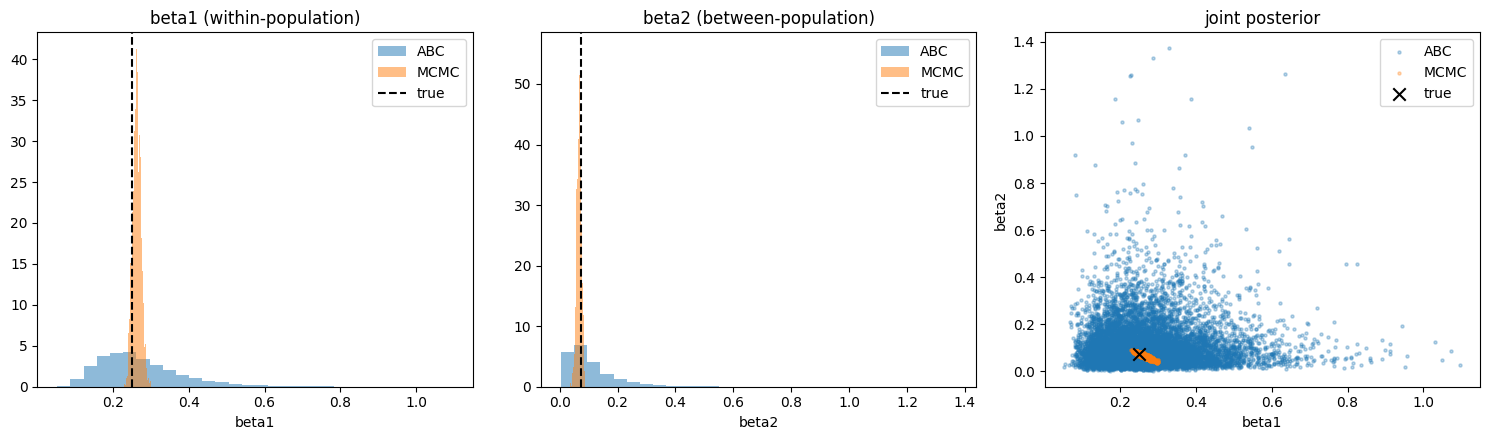

In [69]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].hist(abc_posterior.beta1, bins=30, alpha=0.5, density=True, label="ABC")
axes[0].hist(mcmc_beta1, bins=30, alpha=0.5, density=True, label="MCMC")
axes[0].axvline(true_beta1, color="k", linestyle="--", label="true")
axes[0].set_title("beta1 (within-population)")
axes[0].set_xlabel("beta1")
axes[0].legend()

axes[1].hist(abc_posterior.beta2, bins=30, alpha=0.5, density=True, label="ABC")
axes[1].hist(mcmc_beta2, bins=30, alpha=0.5, density=True, label="MCMC")
axes[1].axvline(true_beta2, color="k", linestyle="--", label="true")
axes[1].set_title("beta2 (between-population)")
axes[1].set_xlabel("beta2")
axes[1].legend()

axes[2].scatter(abc_posterior.beta1, abc_posterior.beta2, s=5, alpha=0.3, label="ABC")
axes[2].scatter(mcmc_beta1, mcmc_beta2, s=5, alpha=0.3, label="MCMC")
axes[2].scatter([true_beta1], [true_beta2], color="k", marker="x", s=80, label="true")
axes[2].set_title("joint posterior")
axes[2].set_xlabel("beta1")
axes[2].set_ylabel("beta2")
axes[2].legend()

fig.tight_layout()
plt.show()

```{exercise}
:label: ex13.6

1. Discuss in pairs what these plots are showing.
2. Do you think the correlation between `beta1` and `beta2` is a bug, or a genuine feature of the model? Why?
3. Plot the prior distributions for `beta1` and `beta2` on top of the posterior histograms above. How much has each distribution changed, going from prior to posterior?
```

````{solution-start} ex13.6
:class: dropdown
````

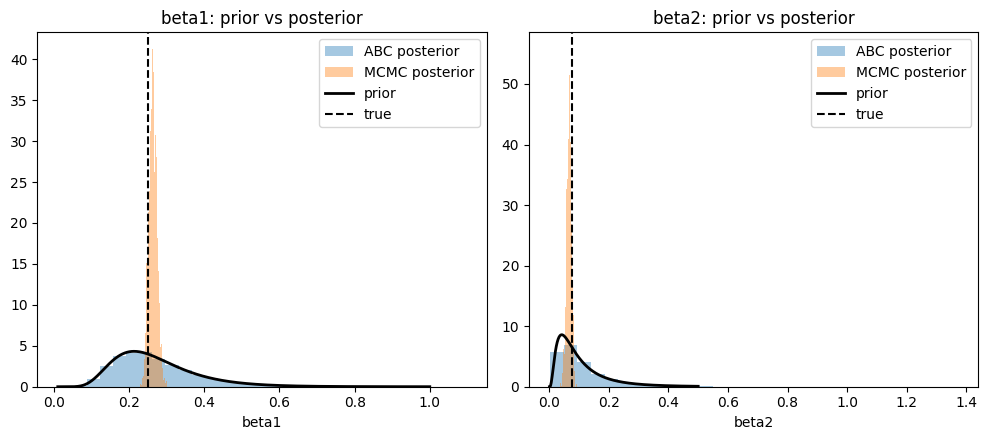

In [70]:
beta1_prior = tfd.LogNormal(loc=jnp.log(DTYPE(0.25)), scale=DTYPE(0.4))
beta2_prior = tfd.LogNormal(loc=jnp.log(DTYPE(0.08)), scale=DTYPE(0.8))

beta1_grid = jnp.linspace(0.01, 1.0, 500)
beta2_grid = jnp.linspace(0.001, 0.5, 500)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

axes[0].hist(
    abc_posterior.beta1, bins=30, alpha=0.4, density=True, label="ABC posterior"
)
axes[0].hist(mcmc_beta1, bins=30, alpha=0.4, density=True, label="MCMC posterior")
axes[0].plot(beta1_grid, beta1_prior.prob(beta1_grid), "k-", lw=2, label="prior")
axes[0].axvline(true_beta1, color="k", linestyle="--", label="true")
axes[0].set_title("beta1: prior vs posterior")
axes[0].set_xlabel("beta1")
axes[0].legend()

axes[1].hist(
    abc_posterior.beta2, bins=30, alpha=0.4, density=True, label="ABC posterior"
)
axes[1].hist(mcmc_beta2, bins=30, alpha=0.4, density=True, label="MCMC posterior")
axes[1].plot(beta2_grid, beta2_prior.prob(beta2_grid), "k-", lw=2, label="prior")
axes[1].axvline(true_beta2, color="k", linestyle="--", label="true")
axes[1].set_title("beta2: prior vs posterior")
axes[1].set_xlabel("beta2")
axes[1].legend()

fig.tight_layout()
plt.show()

````{solution-end}
````

### References